---
title: Human single-cell HiC for X and Y bearing sperm
date: last-modified
author: Kasper Munch

---

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# %config InlineBackend.figure_format='svg'
%config InlineBackend.figure_format='retina'

import cooler
import cooltools
import bioframe
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

from geneinfo.genelist import GeneListCollection
from geneinfo.genelist import GeneList as glist
from geneinfo.coords import gene_coords, gene_labels, gene_coords_region

from vscodenb import set_vscode_theme, vscode_theme
set_vscode_theme()
# if any(x in os.environ for x in ["VSCODE_PID", "VSCODE_CWD", "JPY_PARENT_PID"]):
#     plt.rcParams['figure.facecolor'], plt.rcParams['axes.facecolor'] = '#1F1F1F', '#1F1F1F'



In [3]:
sheet = GeneListCollection(google_sheet='1JSjSLuto3jqdEnnG7JqzeC_1pUZw76n7XueVAYrUOpk')

Download human genome hg38 FASTA if not already present:

In [4]:
import urllib.request
import gzip
import shutil

hg38_url = "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz"
hg38_fasta_path = "../data/hg38.fa"
hg38_gz_path = "../data/hg38.fa.gz"

if not os.path.exists(hg38_fasta_path):
    print("Downloading hg38 genome...")
    urllib.request.urlretrieve(hg38_url, hg38_gz_path)
    
    print("Extracting hg38 genome...")
    with gzip.open(hg38_gz_path, 'rb') as f_in:
        with open(hg38_fasta_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    
    # Remove the compressed file to save space
    os.remove(hg38_gz_path)
    print("hg38 genome downloaded and extracted successfully")
else:
    print("hg38 genome already exists")

hg38 genome already exists


---

## From other notebooks:

#### Load gene information for the X chromosome

In [5]:
all_NPX_genes = gene_coords_region('chrX', 2781479, 156030895, assembly='hg38', as_dataframe=True).drop_duplicates('name').name.sort_values()

#### Calling and plotting compartments

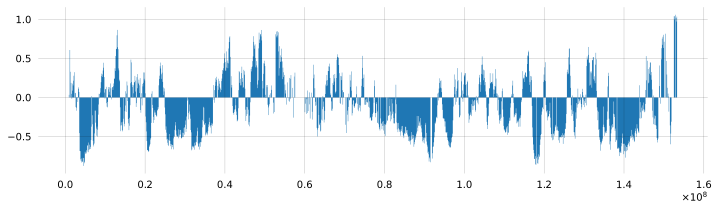

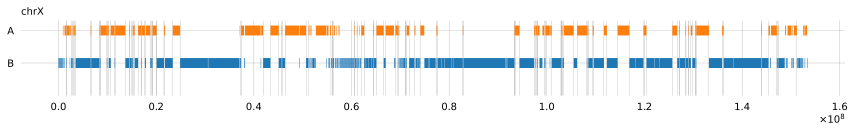

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format='svg'

def plot_intervals(query=None, annot=None, **kwargs):

    import matplotlib.pyplot as plt

    vlines = kwargs.get('vlines', [])
    if 'vlines' in kwargs: del kwargs['vlines']
    figsize = kwargs.get('figsize', (8, 1.5*len(kwargs)-1))
    if 'figsize' in kwargs: del kwargs['figsize']

    tups = list(kwargs.items())
    tups = reversed(tups)

    df_list = []
    labels = []
    for label, df in tups:
        labels.append(label)
        df['label'] = np.repeat(label, df.index.size)
        df_list.append(df)
    bigdf = pd.concat(df_list)

    bigdf['chrom'] = pd.Categorical(bigdf['chrom'], bigdf['chrom'].unique())
    bigdf['label'] = pd.Categorical(bigdf['label'], bigdf['label'].unique())

    gr = bigdf.groupby('chrom', observed=False)

    fig, axes = plt.subplots(gr.ngroups, 1, figsize=figsize, 
                            sharey=True
                            #  sharex=True
                             )
    if type(axes) is not np.ndarray:
        # in case there is only one axis so it not returned as a list
        axes = [axes]
    
    for i, chrom in enumerate(gr.groups):
        _df = gr.get_group(chrom)
        _gr = _df.groupby('label', observed=False)
        for y, label in enumerate(_gr.groups):
            try:
                df = _gr.get_group(label)
            except KeyError:
                continue
            y = np.repeat(y, df.index.size)
            axes[i].hlines(y, df.start.tolist(), df.end.tolist(), lw=10, colors=f'C{y[0]}', capstyle='butt')
            delta = len(labels)/10

        axes[i].spines['top'].set_visible(False)
        axes[i].spines['left'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

        axes[i].set_yticks(list(range(len(labels))), labels)
        axes[i].tick_params(axis='y', which='both', left=False)
        axes[i].set_ylim(-1, len(labels)-0.7)
        # axes[i].set_xlim(df.start.min()-delta, df.end.max()+delta)
        if i != gr.ngroups-1:
            axes[i].tick_params(axis='x', which='both', bottom=False)

        axes[i].set_title(chrom, loc='left', fontsize=10)

    for y, ax in enumerate(axes):
        y = np.repeat(y, len(vlines))
        axes[i].vlines(vlines, *ax.get_ylim(), lw=0.1, colors='black', zorder=0)
    
    plt.tight_layout()
    return axes

def stairs(df, start='start', end='end', pos='pos', endtrim=0):
    "Turn a df with start, end into one with pos to plot as stairs"
    df1 = df.copy(deep=True)
    df2 = df.copy(deep=True)
    df1[pos] = df1[start]
    df2[pos] = df2[end] - endtrim
    return pd.concat([df1, df2]).sort_values([start, end])
## Read in 100kb windows
e1_100kb = pd.read_csv('../../cDEGexploration/data/rec_compartments/round_spermatid_e1_100kb_arms.csv')
e1_100kb['start'] = [i*100_000 for i in range(e1_100kb.index.size)]
e1_100kb['end'] = e1_100kb.start + 100_000
e1_100kb['sign'] = np.sign(e1_100kb.e1)

plot_df = stairs(e1_100kb)
plt.figure(figsize=(12, 3))
plt.fill_between(plot_df.pos, plot_df.e1) ;
## Call compartments
e1_100kb['segment_id'] = ((e1_100kb.sign.shift() != e1_100kb.sign)).cumsum()

comp = e1_100kb.groupby('segment_id', as_index=False).agg(dict(
     e1=['mean', 'sum'], 
     start='min', 
     end='max', 
     segment_id='mean', 
     sign='mean'
))
comp.columns = ['_'.join(col).strip() for col in comp.columns.values]
comp = comp.rename(
    columns={'start_min':'start',
             'end_max':'end', 
             'segment_id_mean':'segment_id', 
             'sign_mean':'sign'}
)
comp['comp'] = ['A' if x > 0 else 'B' for x in comp.sign]
comp = comp.reset_index()
comp['chrom'] = 'chrX'
## Call edges where both A and B flanking 100kb windwos have data
_comp = comp.copy()
for i in range(1, _comp.index.size-1):
    if np.isnan(_comp.loc[i-1, 'e1_mean']):
        _comp.loc[i, 'start'] = np.nan
    if np.isnan(_comp.loc[i+1, 'e1_mean']):
        _comp.loc[i, 'end'] = np.nan
_comp = _comp.loc[~_comp.e1_mean.isnull(), :]
_comp = _comp.reset_index()
edges = pd.concat([_comp.start, _comp.end]).sort_values().unique()
## Plot compartmnet and defined edges
compartments = comp.loc[~comp.e1_mean.isnull()].copy()
compartments['start'] = compartments.start.astype(int)
compartments['end'] = compartments.end.astype(int)

axes = plot_intervals(
    A=comp.loc[comp.comp == 'A', :].copy(),
    B=comp.loc[comp.comp == 'B', :].copy(),   
    vlines=edges.tolist(),
    figsize=(12, 2)
)
compartments.to_csv('compartments.csv')
edge_segments = pd.DataFrame(np.column_stack((edges-100_000, edges+100_000)), columns=['start', 'end'])
edge_segments['chrom'] = 'chrX'
edge_segments.to_csv('edge_segments.csv')

#### Read in 100kb windows

In [7]:
gene_labels(['OGT'], assembly='hg38')

[('chrX', 71554497.5, 'OGT')]

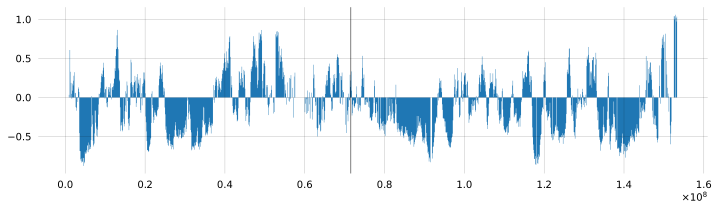

In [8]:
e1_100kb = pd.read_csv('../../cDEGexploration/data/rec_compartments/round_spermatid_e1_100kb_arms.csv')
e1_100kb['start'] = [i*100_000 for i in range(e1_100kb.index.size)]
e1_100kb['end'] = e1_100kb.start + 100_000
e1_100kb['sign'] = np.sign(e1_100kb.e1)

plot_df = stairs(e1_100kb)
plt.figure(figsize=(12, 3))
plt.fill_between(plot_df.pos, plot_df.e1) ;

plt.axvline(71554497.5, color='black', lw=0.5)

#### Call compartments

In [9]:
e1_100kb['segment_id'] = ((e1_100kb.sign.shift() != e1_100kb.sign)).cumsum()

comp = e1_100kb.groupby('segment_id', as_index=False).agg(dict(
     e1=['mean', 'sum'], 
     start='min', 
     end='max', 
     segment_id='mean', 
     sign='mean'
))
comp.columns = ['_'.join(col).strip() for col in comp.columns.values]
comp = comp.rename(
    columns={'start_min':'start',
             'end_max':'end', 
             'segment_id_mean':'segment_id', 
             'sign_mean':'sign'}
)
comp['comp'] = ['A' if x > 0 else 'B' for x in comp.sign]
comp = comp.reset_index()
comp['chrom'] = 'chrX'

#### Call edges where both A and B flanking 100kb windwos have data

In [10]:
_comp = comp.copy()
for i in range(1, _comp.index.size-1):
    if np.isnan(_comp.loc[i-1, 'e1_mean']):
        _comp.loc[i, 'start'] = np.nan
    if np.isnan(_comp.loc[i+1, 'e1_mean']):
        _comp.loc[i, 'end'] = np.nan
_comp = _comp.loc[~_comp.e1_mean.isnull(), :]
_comp = _comp.reset_index()
edges = pd.concat([_comp.start, _comp.end]).sort_values().unique()

#### Plot compartmnet and defined edges

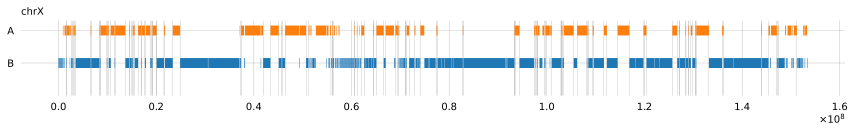

In [11]:
compartments = comp.loc[~comp.e1_mean.isnull()].copy()
compartments['start'] = compartments.start.astype(int)
compartments['end'] = compartments.end.astype(int)

axes = plot_intervals(
    A=comp.loc[comp.comp == 'A', :].copy(),
    B=comp.loc[comp.comp == 'B', :].copy(),   
    vlines=edges.tolist(),
    figsize=(12, 2)
)

In [12]:
compartments.to_csv('compartments.csv')

In [13]:
edge_segments = pd.DataFrame(np.column_stack((edges-100_000, edges+100_000)), columns=['start', 'end'])
edge_segments['chrom'] = 'chrX'
edge_segments.to_csv('edge_segments.csv')

---

In [1]:
# Set the window size to select in cooler
hic_resolution = 50_000  


def gc_covariance(chrom, clr, hic_resolution):
    bins = clr.bins().fetch(chrom)[:]
    out_name = f'hg38_gc_{chrom}_res{hic_resolution}bp.tsv'
    hg38 = bioframe.load_fasta('../data/hg38.fa')
    if not os.path.exists(out_name):
        gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38)
        gc_cov.to_csv(out_name, index=False,sep='\t')
    else: 
        gc_cov = pd.read_csv(out_name, sep='\t')
    return gc_cov

def get_eigen_vectors(clr, chrom, hic_resolution):
    idx = clr.chromnames.index(chrom)
    view_df = pd.DataFrame({
        'chrom': clr.chromnames[idx],
        'start': [0],
        'end': clr.chromsizes.values[idx],
        'name': clr.chromnames[idx]})

    gc_cov = gc_covariance(chrom, clr, hic_resolution)
    eig_val, eig_vec = cooltools.eigs_cis(clr, gc_cov, view_df=view_df, n_eigs=1)
    eig_vec['sign'] = np.sign(eig_vec['E1'])
    eig_vec['segment_id'] = ((eig_vec.sign.shift() != eig_vec.sign)).cumsum()    
    eig_vec['compart'] = ['A' if x > 0 else 'B' for x in eig_vec.sign]
    return eig_vec[['chrom', 'start', 'end', 'E1', 'compart']]





autosomes = [f'chr{x}' for x in range(1, 23)]

hic_dir = '../../cDEGexploration/data/human_sperm_haplo_seperated'

# autosome data for Y bearing sperm
clr_path = f"{hic_dir}/sperm_Y.merged.mcool"
clr = cooler.Cooler(f"{clr_path}::resolutions/{hic_resolution}")
auto_y_sperm = pd.concat(
    [get_eigen_vectors(clr, chrom, hic_resolution) for chrom in autosomes]
    ).reset_index(drop=True)


# autosome data for X bearing sperm
clr_path = "../../cDEGexploration/data/human_sperm_haplo_seperated/sperm_X.merged.mcool"
clr = cooler.Cooler(f"{clr_path}::resolutions/{hic_resolution}")
auto_x_sperm = pd.concat(
    [get_eigen_vectors(clr, chrom, hic_resolution) for chrom in autosomes]
    ).reset_index(drop=True)

# data for chrX
chrX_compart = get_eigen_vectors(clr, 'chrX', hic_resolution)

# combine the X and Y bearing sperm data for autosomes
autosome_compart = auto_x_sperm.merge(auto_y_sperm, 
                                          on=['chrom', 'start', 'end'], 
                                          how='outer', suffixes=('_X', '_Y'))

NameError: name 'cooler' is not defined

In [15]:
autosome_compart.head()

NameError: name 'autosome_compart' is not defined

In [14]:
# df = autosome_compart.copy()
# #df.loc[df.E1.isnull(), 'E1'] = np.nan
# df.to_csv("~/Desktop/autosome_compart.csv", index=False)

In [15]:
chrX_compart.head()

,chrom,start,end,E1,compart
57509,chrX,0,50000,NaN,B
57510,chrX,50000,100000,NaN,B
57511,chrX,100000,150000,NaN,B
57512,chrX,150000,200000,NaN,B
57513,chrX,200000,250000,NaN,B


In [16]:
# df = chrX_compart.copy()
# #df.loc[df.E1.isnull(), 'E1'] = np.nan
# df.to_csv("~/Desktop/chrX_compartments.csv", index=False)


In [17]:
df = chrX_compart
ab_edges = df[~df.E1.isnull() & ~df.E1.shift().isnull() & (df.compart != df.compart.shift())].start
ab_edges

57600      4550000
57601      4600000
57621      5600000
57622      5650000
57678      8450000
           ...    
60449    147000000
60450    147050000
60451    147100000
60459    147500000
60460    147550000
Name: start, Length: 245, dtype: int32

In [18]:
import geneinfo
flank = 50_000
lst = [geneinfo.coords.gene_labels_region('chrX', x-flank, x+flank, assembly='hg38') for x in ab_edges]
ab_border_genes = glist(sorted(set([tup[2] for sublist in lst for tup in sublist]))).name('A/B border')

In [19]:
ab_border_genes

ABCB7,DYNLT3,LINC01285,LOC124905213,MIR766,SNORA35
ACTRT1,EIF1AX,LINC02601,LOC124905214,MIR891A,SOX3
ADGRG2,EIF1AX-AS1,LINC03113,LOC124905215,MIR891B,SPANXA2-OT1
AIFM1,ELF4,LOC101928201,LOC124905216,NDUFA1,SPANXD
AKAP14,ENOX2,LOC101928415,LOC124905217,NEXMIF,SPANXN1
AKAP17BP,ENOX2-AS1,LOC101928437,LOC124905222,NKAPP1,SPANXN3
AMOT,ESX1,LOC101928808,LOC124905236,NKRF,SPANXN4
ANOS1,F9,LOC101928832,LOC124905258,NUP62CL,SRD5A1P1
APLN,FAM47C,LOC102724491,LOC124905259,NXF3,SRPX2
ARL13A,FGF13,LOC105373146,LOC124905273,NYX,STEEP1
ARMCX1,FGF13-AS1,LOC105373155,LOC645188,OCRL,SYTL4


In [20]:
ab_border_genes.fisher(sheet.get('cDEG'), sheet.get('all_npx'))

LINC03113 


Removed 1 genes not in background set


0.0008199409665606614

In [21]:
ab_border_genes.fisher(sheet.get('sfari_all_conf'), sheet.get('all_npx'))

LINC03113 


Removed 1 genes not in background set


0.18160379810771007

## Plots

In [22]:
def stairs(df, start='start', end='end', pos='pos', endtrim=0):
    "Turn a df with start, end into one with pos to plot as stairs"
    df1 = df.copy(deep=True)
    df2 = df.copy(deep=True)
    df1[pos] = df1[start]
    df2[pos] = df2[end] - endtrim
    return pd.concat([df1, df2]).sort_values([start, end])

### Plot for chrX

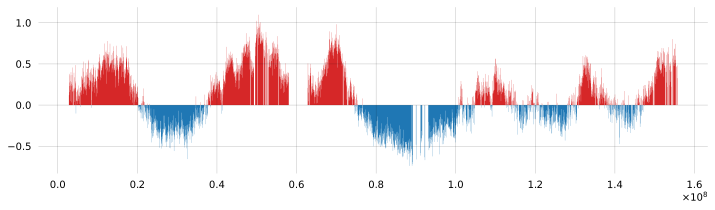

In [23]:
df = stairs(chrX_compart)
x, y = df['pos'], df['E1']
f, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(x, y, 0, where=(y > 0), ec='none', fc='tab:red', alpha=1)
ax.fill_between(x, y, 0, where=(y < 0), ec='none', fc='tab:blue', alpha=1) ;

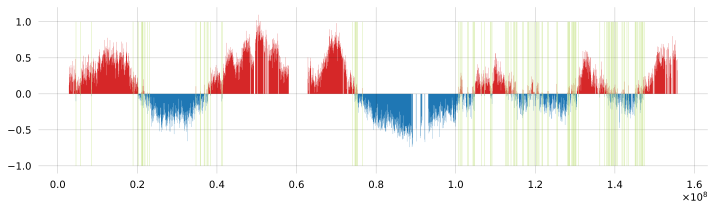

In [24]:
df = stairs(chrX_compart)
x, y = df['pos'], df['E1']
f, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(x, y, 0, where=(y > 0), ec='none', fc='tab:red', alpha=1)
ax.fill_between(x, y, 0, where=(y < 0), ec='none', fc='tab:blue', alpha=1)
ax.vlines(ab_edges, -1, 1, color='yellowgreen', lw=0.1) ;


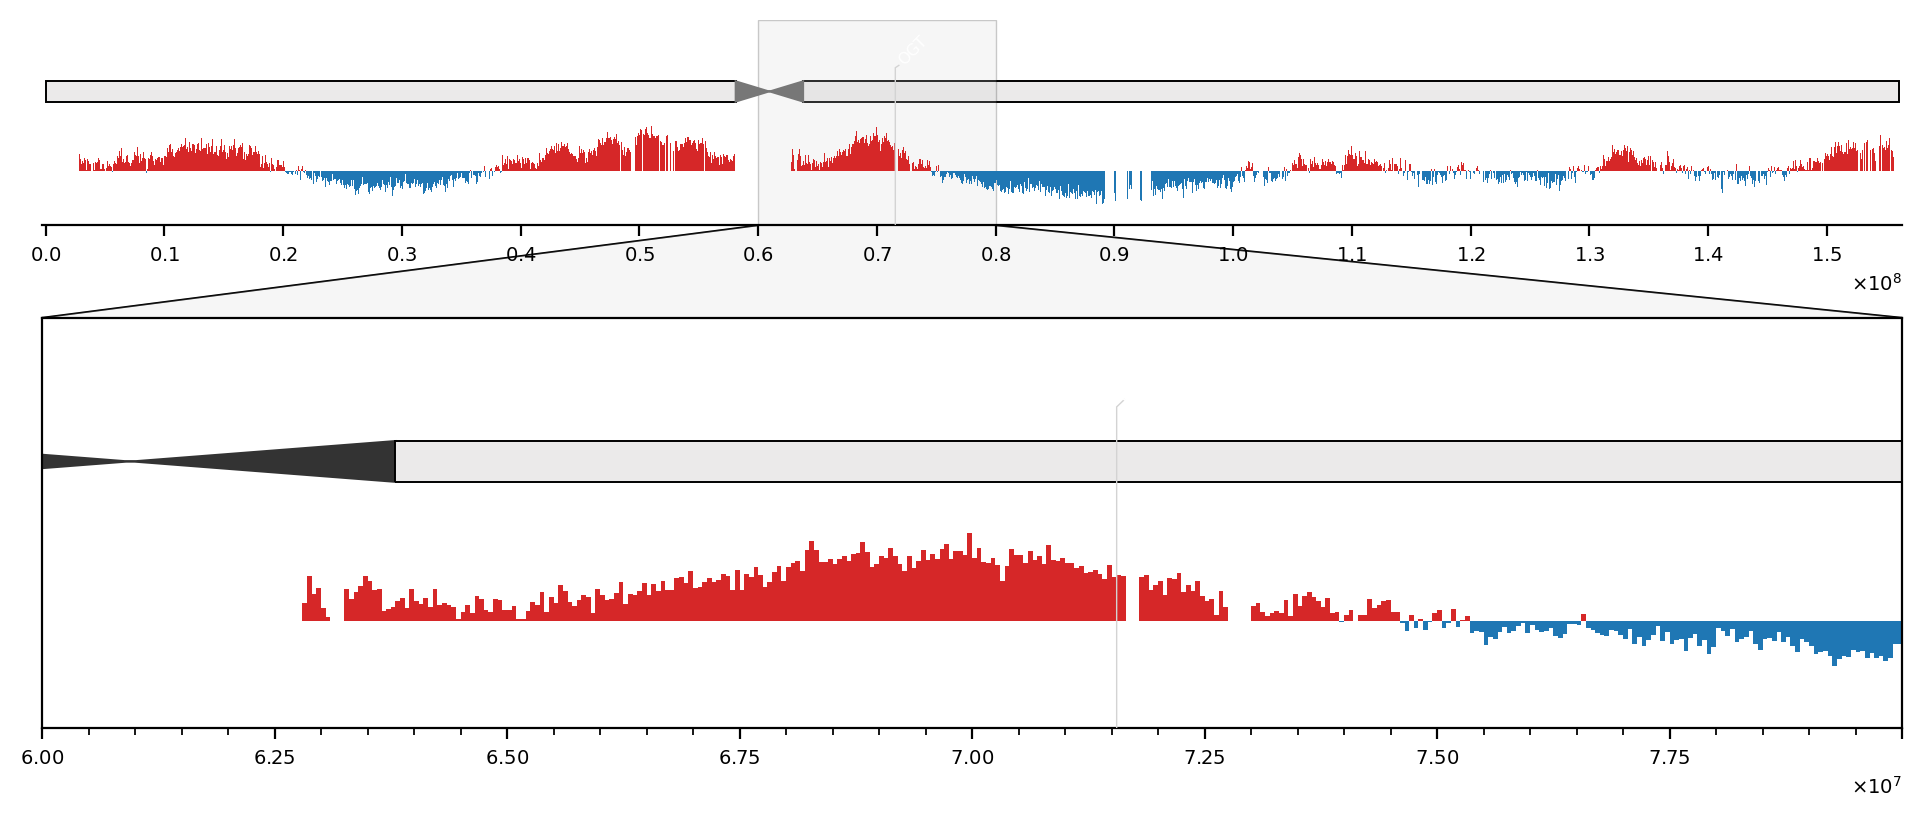

In [37]:
from geneinfo.plot import ChromIdeogram
from geneinfo.coords import gene_labels

df = stairs(chrX_compart)
x, y = df['pos'], df['E1']

from matplotlib.axes import Axes
plot_df = pd.DataFrame(dict(x=x, y=y))
plot_df['chrom'] = 'chrX'
plot_df['y2'] = 0

with vscode_theme(style='ticks', frame=True):

    g = ChromIdeogram('chrX', assembly='hg38', 
                        font_size=4,
                        # ylim=(0, 20),
                        zoom_height_ratio=2, 
                        zoom_font_size=5, 
                        zoom_effect_alpha=0.2,
                            zooms=[
            (60_000_000, 80_000_000),
        ]
                        )

    g.draw_chromosomes(base=6, height=1)

    g.map_method(Axes.fill_between, data=plot_df, x='x', y='y', y2='y2', yaxis=(1, 5), color='tab:red', where=plot_df.y > plot_df.y2, ec='none')                   
    g.map_method(Axes.fill_between, data=plot_df, x='x', y='y', y2='y2', yaxis=(1, 5), color='tab:blue', where=plot_df.y < plot_df.y2, ec='none')

    # g.add_labels(gene_labels(sheet.get('hybridDEG'), assembly='rheMac10'), base=0, min_height=g.ideogram_base+g.ideogram_height*2, colored=sheet.get('cDEG'))
    g.add_labels(gene_labels(['OGT'], assembly='hg38'), base=0, min_height=g.ideogram_base+g.ideogram_height*2)


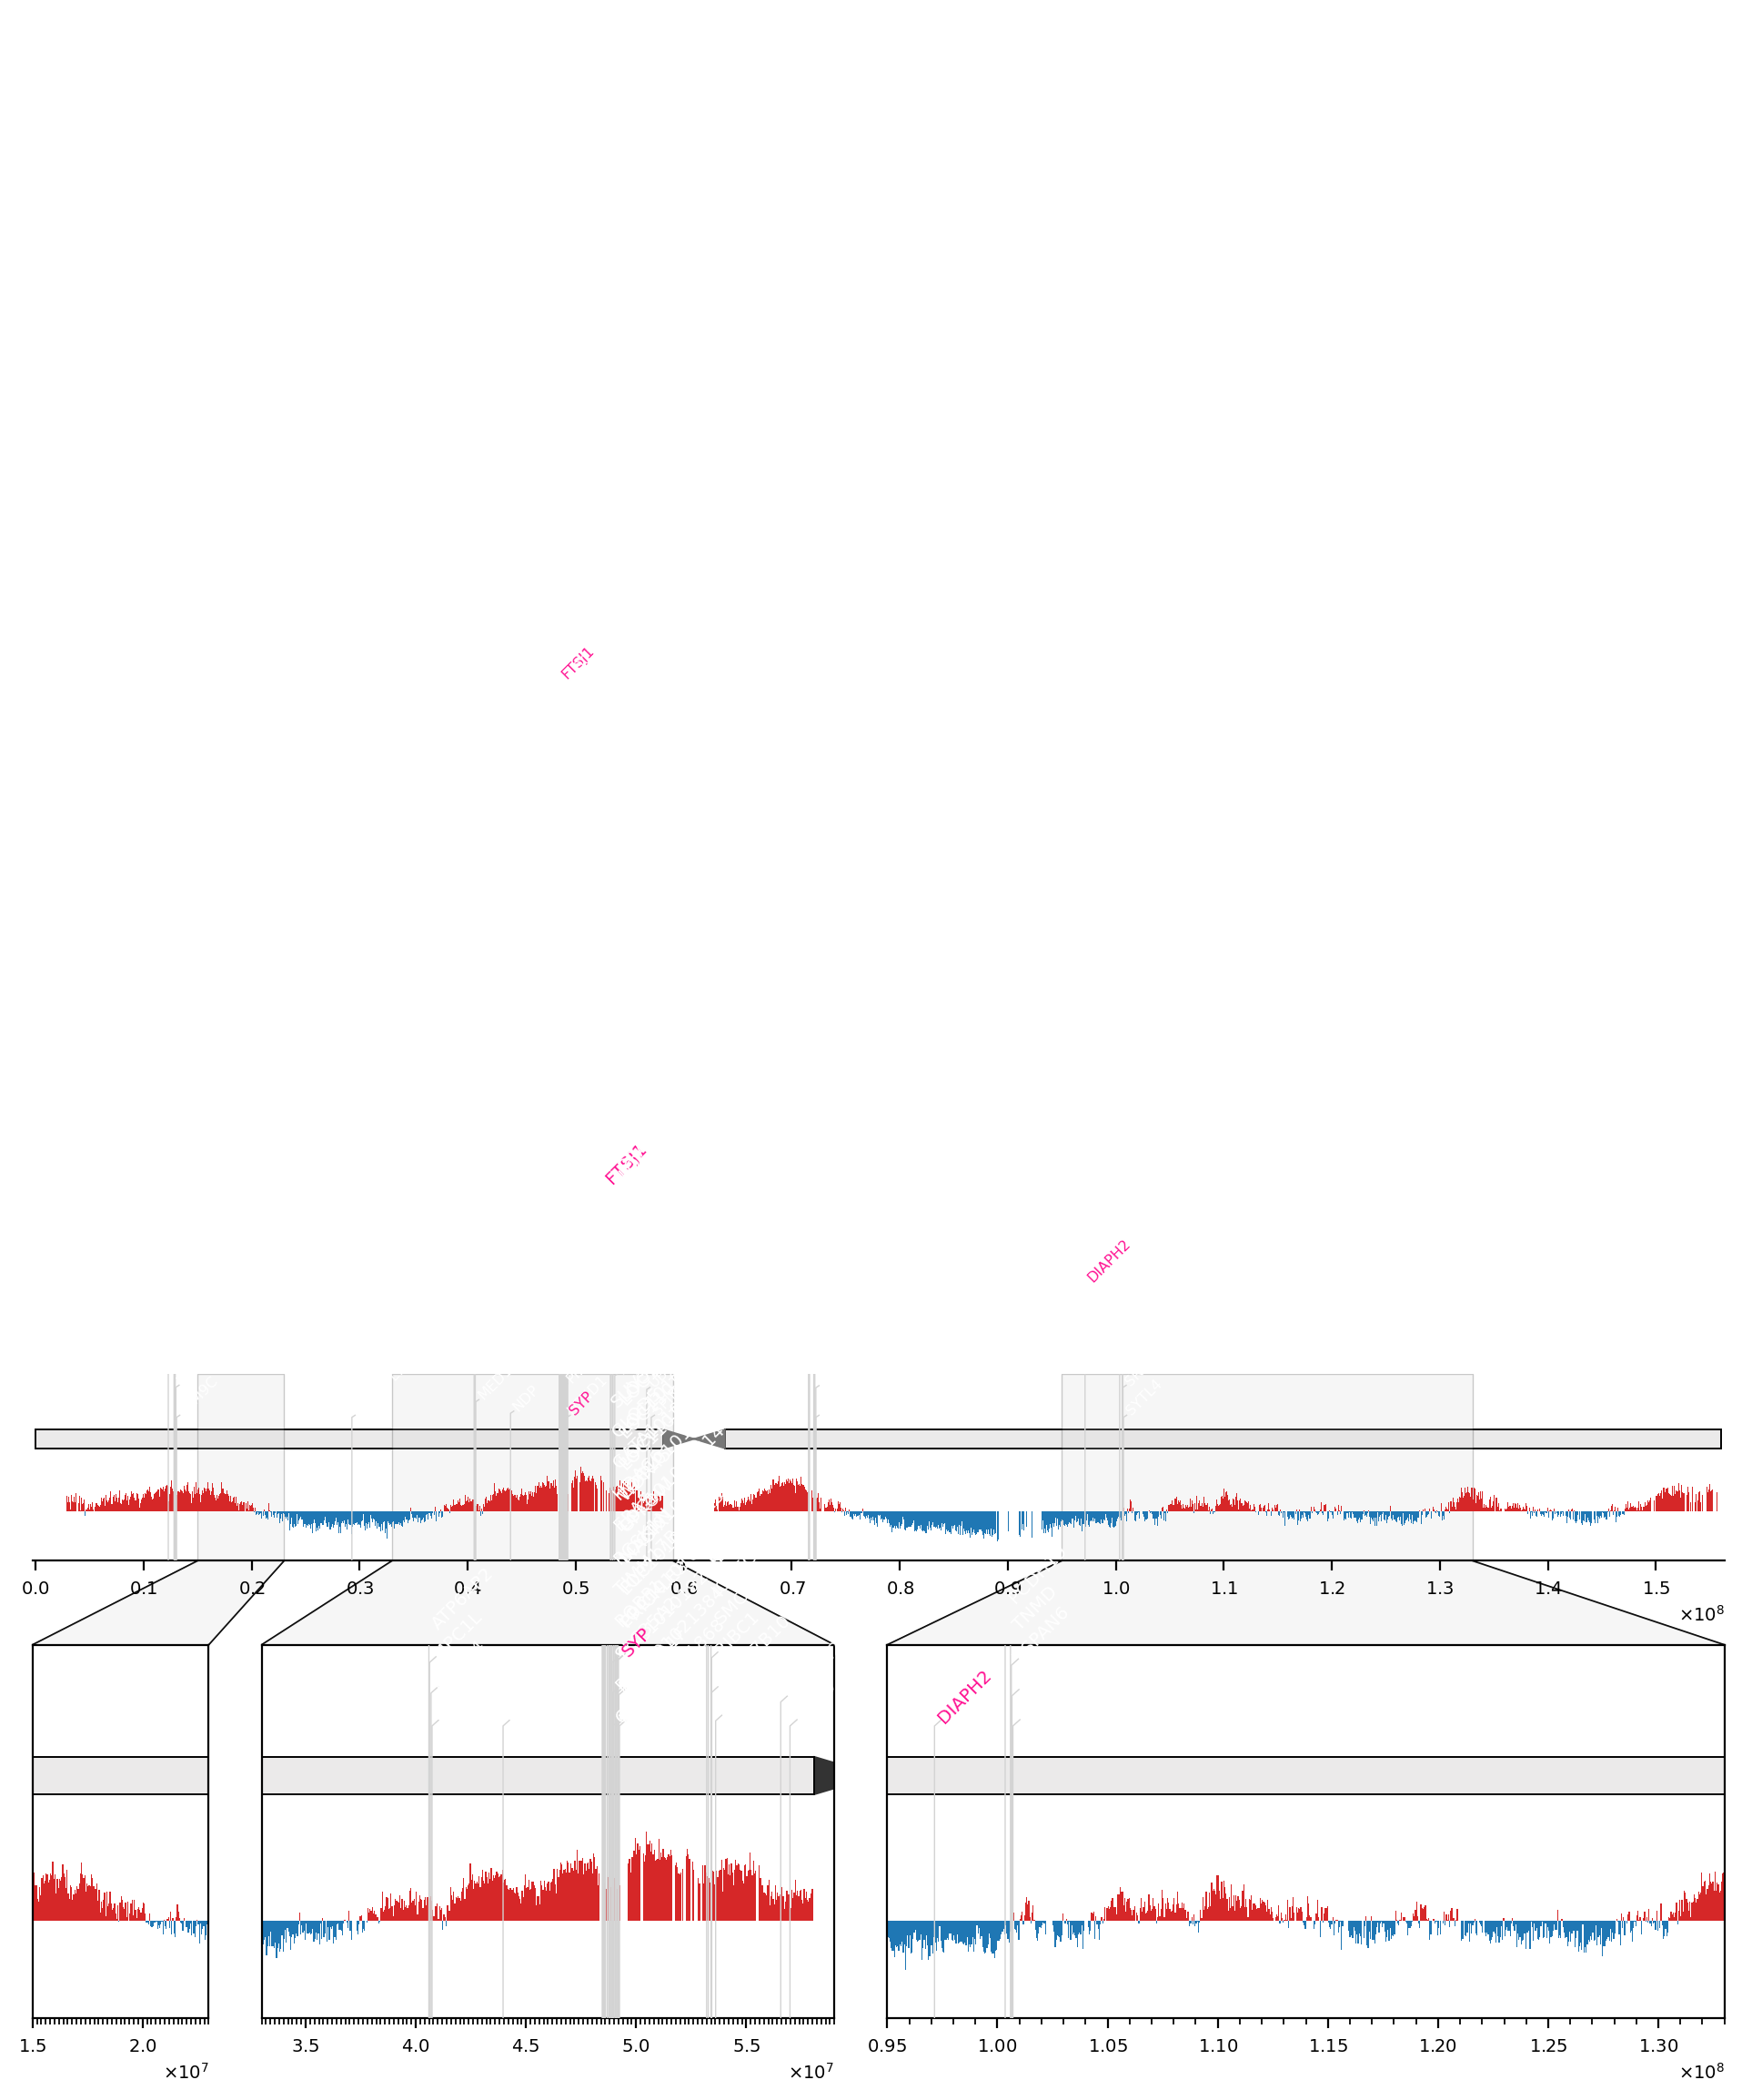

In [29]:
from geneinfo.plot import ChromIdeogram
from geneinfo.coords import gene_labels

df = stairs(chrX_compart)
x, y = df['pos'], df['E1']

from matplotlib.axes import Axes
plot_df = pd.DataFrame(dict(x=x, y=y))
plot_df['chrom'] = 'chrX'
plot_df['y2'] = 0

with vscode_theme(style='ticks', frame=True):

    g = ChromIdeogram('chrX', assembly='hg38', 
                        font_size=4,
                        ylim=(0, 10),
                        zoom_height_ratio=2, 
                        zoom_font_size=5, 
                        zoom_effect_alpha=0.2,
    #                       ylim=(0, 10),
                            zooms=[
            (15_000_000, 23_000_000),
            (33_000_000, 59_000_000),
            (95_000_000, 133_000_000),
        ]
                        )

    g.draw_chromosomes(base=6, height=1)

    # g.add_segments([(t.chrom, t.start, t.end) for t in olive_pure_segments.itertuples()], 
    #                facecolor='tab:green', base=3, height=1, label='Pure olive', alpha=0.7)
    # g.add_segments([(t.chrom, t.start, t.end) for t in hama_pure_segments.itertuples()], 
    #                facecolor='tab:orange', base=2, height=1, label='Pure hamadryas', alpha=0.7)

    # g.map_method(Axes.fill_between, data=plot_df, 
    #              x='x', y='y', yaxis=(1.5, 2.5), label='A',
    #              where=(y > 0), ec='none', fc='tab:red', interpolate=False, step='pre')
    # g.map_method(Axes.fill_between, data=plot_df, 
    #              x='x', y='y', yaxis=(1.5, 2.5), label='B',
    #              where=(y < 0), ec='none', fc='tab:blue', interpolate=False, step='pre')


    # plot_df = pd.DataFrame(dict(x=x*100000, y=y))
    # plot_df['y2'] = 0
    # plot_df['chrom'] = 'chrX'
    g.map_method(Axes.fill_between, data=plot_df, x='x', y='y', y2='y2', yaxis=(1, 5), color='tab:red', where=plot_df.y > plot_df.y2, ec='none')                   
    g.map_method(Axes.fill_between, data=plot_df, x='x', y='y', y2='y2', yaxis=(1, 5), color='tab:blue', where=plot_df.y < plot_df.y2, ec='none')

    # g.add_labels(gene_labels(sheet.get('hybridDEG'), assembly='rheMac10'), base=0, min_height=g.ideogram_base+g.ideogram_height*2, colored=sheet.get('cDEG'))
    g.add_labels(gene_labels(sheet.get('pure_hama'), assembly='hg38'), base=0, min_height=g.ideogram_base+g.ideogram_height*2, colored=sheet.get('cDEG'))




    # g.map_method(Axes.scatter, data=plot_df.loc[plot_df.y < 0], 
    #             x='x', y='y', yaxis=(0.1, 3), label='B compartment',
    #             s=4, ec='none', fc='tab:blue')
    # g.map_method(Axes.scatter, data=plot_df.loc[plot_df.y > 0], 
    #             x='x', y='y', yaxis=(3, 5.9), label='A compartment',
    #             s=4, ec='none', fc='tab:red')

    # # new_ax = g.add_axes(1, height_ratio=0.6, hspace=0.5)
    # # new_ax.fill_between(x, y, 0, where=(y > 0), ec='none', fc='tab:red', interpolate=False, step='pre')
    # # new_ax.fill_between(x, y, 0, where=(y < 0), ec='none', fc='tab:blue', interpolate=False, step='pre')
    # # new_ax.axis('off')
    # # # new_ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize="10", frameon=False)

    # coords = gene_labels(sheet.get('cDEG'), assembly='hg38')
    # g.add_labels(coords, base=g.ideogram_base, min_height=g.ideogram_height*4, 
    #             zoom_base=g.ideogram_base, zoom_min_height=g.ideogram_height*3, color='black')
    # g.add_legend(loc='center left', bbox_to_anchor=(0.82, 1.3), fontsize="10", frameon=False)

In [26]:
from matplotlib.axes import Axes
plot_df = pd.DataFrame(dict(x=(df.start + df.end) / 2, y=df.E1))
plot_df['chrom'] = 'chrX'
plot_df['midline'] = 3
plot_df

,x,y,chrom,midline
57509,25000.0,NaN,chrX,3
57509,25000.0,NaN,chrX,3
57510,75000.0,NaN,chrX,3
57510,75000.0,NaN,chrX,3
57511,125000.0,NaN,chrX,3
...,...,...,...,...
60627,155925000.0,NaN,chrX,3
60628,155975000.0,NaN,chrX,3
60628,155975000.0,NaN,chrX,3
60629,156020447.5,NaN,chrX,3


TypeError: Axes.vlines() got multiple values for argument 'ymin'

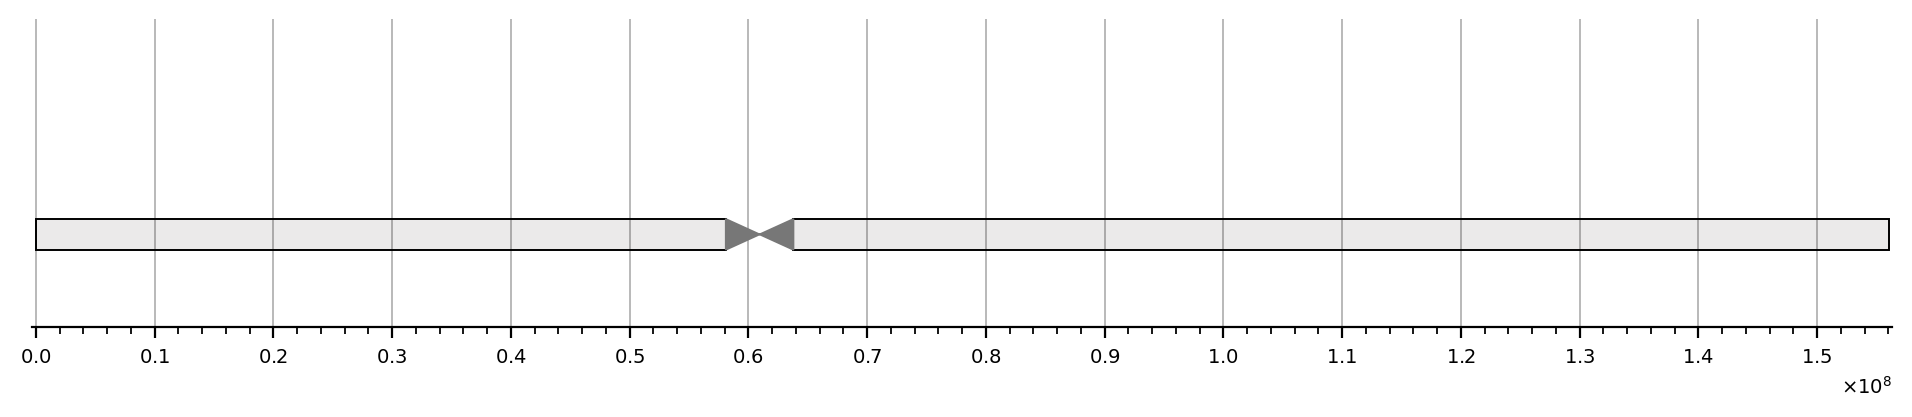

In [27]:
g = ChromIdeogram('chrX', assembly='hg38', 
                    font_size=5,
#                        zoom_height_ratio=2, 
#                        zoom_font_size=5, 
#                        zoom_effect_alpha=0.2,
# #                       ylim=(0, 10),
#                           zooms=[
#         (15_000_000, 23_000_000),
#         (33_000_000, 59_000_000),
#         (95_000_000, 133_000_000),
#     ]
                      )

g.draw_chromosomes(base=2.5, height=1)

g.map_method(Axes.vlines, data=plot_df.loc[plot_df.y < 0], 
             x='x', ymin='y', ymax='y', yaxis=(0.1, 3), label='B compartment',
             color='tab:blue')

# coords = gene_labels(sheet.get('circRNA'), assembly='hg38')
# g.add_labels(coords, base=g.ideogram_base, min_height=g.ideogram_height*4, 
#              zoom_base=g.ideogram_base, zoom_min_height=g.ideogram_height*3, color='black')
# g.add_legend(loc='center left', bbox_to_anchor=(0.82, 1.3), fontsize="10", frameon=False)

### Plot for some autosome

In [ ]:
chrom = 'chr8'
carrying = 'X'
compartments_chrom = autosome_compart[autosome_compart.chrom == chrom].reset_index(drop=True)

df = stairs(compartments_chrom)
x, y = df['pos'], df[f'E1_{carrying}']
f, ax = plt.subplots(figsize=(8, 3))
ax.fill_between(x, y, 0, where=(y > 0), ec='none', fc='tab:red', alpha=1)
ax.fill_between(x, y, 0, where=(y < 0), ec='none', fc='tab:blue', alpha=1)
sns.despine()

### Plot both X and Y bearing sperm on an autosome

In [ ]:
chrom = 'chr8'

f, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5))

carrying = 'X'
compartments_chrom = autosome_compart[autosome_compart.chrom == chrom].reset_index(drop=True)
df = stairs(compartments_chrom)
x, y = df['pos'], df[f'E1_{carrying}']
ax1.fill_between(x, y, 0, where=(y > 0), ec='none', fc='tab:red', alpha=1)
ax1.fill_between(x, y, 0, where=(y < 0), ec='none', fc='tab:blue', alpha=1)

carrying = 'Y'
compartments_chrom = autosome_compart[autosome_compart.chrom == chrom].reset_index(drop=True)
df = stairs(compartments_chrom)
x, y = df['pos'], df[f'E1_{carrying}']
ax2.fill_between(x, y, 0, where=(y > 0), ec='none', fc='tab:red', alpha=1)
ax2.fill_between(x, y, 0, where=(y < 0), ec='none', fc='tab:blue', alpha=1)
sns.despine()

### Plot difference between X and Y bearing sperm on an autosome

In [ ]:
chrom = 'chr8'
compartments_chrom = autosome_compart[autosome_compart.chrom == chrom].reset_index(drop=True)

df = stairs(compartments_chrom)
x, y = df['pos'], df[f'E1_X'] - df[f'E1_Y']
f, ax = plt.subplots(figsize=(8, 3))
ax.fill_between(x, y, 0, where=(y > 0), ec='none', fc='tab:red', alpha=1)
ax.fill_between(x, y, 0, where=(y < 0), ec='none', fc='tab:blue', alpha=1)

In [ ]:
glist(sheet.names)

## YRI chrX

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/Volumes/AluDisk/cDEGexploration/data/haplotypes_demog_sele.sele', sep=' ')
df

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df.pos, -df.when_mutation_has_freq2)

In [ ]:
relate_genes = pd.read_hdf('/Volumes/AluDisk/cDEGexploration/data/chrX_signif.h5')
# relate_genes_afr = relate_genes.loc[(relate_genes.neglog10p > 8.5) & (relate_genes.region=='Africa')]
# relate_genes_afr = relate_genes.loc[relate_genes.region=='Africa']
relate_genes_afr = relate_genes.loc[relate_genes.population!='PUR']
df = relate_genes_afr.groupby('gene').apply(lambda x: x.loc[x.neglog10p == x.neglog10p.max()]).reset_index(drop=True)
relate_nonPUR = glist(df.loc[df.neglog10p > 6].gene).name('Relate nonPUR')
relate_nonPUR

from geneinfo.genelist import GeneList as glist
from geneinfo.plot import ChromIdeogram
from geneinfo.coords import gene_labels

In [ ]:

relate_genes = pd.read_hdf('/Volumes/AluDisk/cDEGexploration/data/chrX_signif.h5')
# relate_genes_afr = relate_genes.loc[(relate_genes.neglog10p > 8.5) & (relate_genes.region=='Africa')]
# relate_genes_afr = relate_genes.loc[relate_genes.region=='Africa']
relate_genes_afr = relate_genes.loc[relate_genes.population!='PUR']
df = relate_genes_afr.groupby('gene').apply(lambda x: x.loc[x.neglog10p == x.neglog10p.max()]).reset_index(drop=True)
_gene_list = glist(df.loc[df.neglog10p > 8].gene).name('Relate nonPUR')
_gene_list

from geneinfo.genelist import GeneList as glist
from geneinfo.plot import ChromIdeogram
from geneinfo.coords import gene_labels

g = ChromIdeogram('chrX', assembly='hg38', 
                    font_size=5,
                    ylim=(0, 15),
                    #    zoom_height_ratio=2, 
#                        zoom_font_size=5, 
#                        zoom_effect_alpha=0.2,
# #                       
#                           zooms=[
#         (15_000_000, 23_000_000),
#         (33_000_000, 59_000_000),
#         (95_000_000, 133_000_000),
#     ]
                      )

g.draw_chromosomes(base=5.5, height=1)

g.map_method(Axes.scatter, data=plot_df.loc[plot_df.y < 0], 
             x='x', y='y', yaxis=(0.1, 6), label='B compartment',
             s=4, ec='none', fc='tab:blue')
g.map_method(Axes.scatter, data=plot_df.loc[plot_df.y > 0], 
             x='x', y='y', yaxis=(6, 11.9), label='A compartment',
             s=4, ec='none', fc='tab:red')


from matplotlib.axes import Axes
plot_df = pd.DataFrame(dict(x=x, y=y))
plot_df['chrom'] = 'chrX'

coords = gene_labels([x for x in _gene_list if not x.startswith('LOC')], assembly='hg38')
g.add_labels(coords, base=g.ideogram_base, min_height=g.ideogram_height*4, 
             zoom_base=g.ideogram_base, zoom_min_height=g.ideogram_height*3, color='black')
g.add_legend(loc='center left', bbox_to_anchor=(0.82, 1.3), fontsize="10", frameon=False)

# pure hama edge genes

In [ ]:
df = pd.read_hdf('/Volumes/AluDisk/cDEGexploration/data/mean_window_df_eth.h5')
meta_data_samples = pd.read_csv("/Volumes/AluDisk/cDEGexploration/data/Papio_metadata_with_clustering.txt", sep =" ")
gog_olives = meta_data_samples.loc[meta_data_samples.Origin == "Gog Woreda, Gambella region, Ethiopia"].PGDP_ID
chrX_lai_eth = df.loc[df.individual.isin(gog_olives) & (df.chrom == 'all_chrX')].groupby(["chrom", "individual", "start", "end"]).mean().reset_index()
chrX_lai_eth.head()

In [ ]:
win_means = chrX_lai_eth.groupby(['start', 'end']).north_sum.mean().reset_index()
win_means.head()

In [ ]:
# #| label: fig-gog-ancestry-prop

# plot_df = utils.stairs(win_means)e
# plt.figure(figsize=(12, 4))
# plt.fill_between(plot_df.pos, plot_df.north_sum)
# plt.axhline(y=95000, color='black', linestyle='dashed')
# sns.despine()

In [ ]:
win_means['pure'] = (win_means.north_sum == 0) | (win_means.north_sum >= 95000)

win_means['segment_id'] = (win_means.pure.shift() != win_means.pure).cumsum()

pure = win_means.groupby('segment_id', as_index=False).agg(dict(
     start='min', 
     end='max', 
     north_sum='mean', 
     pure='mean'
))

pure = pure.loc[pure.pure == 1, :]
pure['species'] = ['hama' if x >= 95000 else 'olive' for x in pure.north_sum]
pure['chrom'] = 'chrX'
pure['start'] = pure.start.astype(int)
pure['end'] = pure.end.astype(int)
pure['north_sum'] = pure.north_sum.astype(int)
olive_pure_segments = pure.loc[pure.species == 'olive', ['chrom', 'start', 'end', 'north_sum']]
hama_pure_segments = pure.loc[pure.species == 'hama', ['chrom', 'start', 'end', 'north_sum']]

In [ ]:
edges = pd.concat(
    [
        # olive_pure_segments.start, olive_pure_segments.end, 
        hama_pure_segments.start, hama_pure_segments.end, 
    ]).sort_values().unique()

flank = 50_000
lst = [geneinfo.coords.gene_labels_region('chrX', max(1, x-flank), x+flank, assembly='papAnu4') for x in edges]
pure_hama_border_genes = glist(sorted(set([tup[2] for sublist in lst for tup in sublist]))).name('Pure hama border genes')


In [ ]:
pure_hama_border_genes

In [ ]:
sheet.get('sfari_all_conf').fisher(sheet.get('cDEG'), sheet.get('all_npx'))

In [ ]:
from geneinfo.plot import venn

sfari_all_conf = sheet.get('sfari_all_conf').name('ASD genes (SFARI database)')
ncDEG = (sheet.get('cDEG') | sheet.get('nDEG')).name('Diff. expr. XY spermatids')
ari_nonPUR = sheet.get('ari_nonPUR').name('Recent positive selection')

venn(
    sfari_all_conf,
    ncDEG,
    ari_nonPUR,
    background=sheet.get('all_npx'),
    petals=5,
    figsize=(6, 5), fontsize=10,
    nrows=1)

SFARI & Selection & Diff. expr.:
CDKL5	CLCN4	HUWE1	IL1RAPL1	PTCHD1

SFARI & Selection:
CASK	CLCN4	FRMPD4	IL1RAPL1	PTCHD1-AS CDKL5	DMD	HUWE1	PTCHD1	TMLHE

Selection & Diff. expr.:
CDKL5	CLCN4	ENOX2	HUWE1	IL1RAPL1	PAK3	PRKX	PTCHD1	RTL4

SFARI & Diff. expr.:
AFF2	CDKL5	GABRA3	IQSEC2	MSL3	OPHN1	PTCHD1	SYP	UPF3B
ATRX	CLCN4	HUWE1	KDM6A	OCRL	PCDH11X	RLIM	TAF1	USP9X
BRWD3	DDX3X	IL1RAPL1	LAS1L	OFD1	PHF8	SMC1A	TSPAN7	WNK3


In [ ]:
sfari_all_conf & ari_nonPUR & ncDEG

In [ ]:
sfari_all_conf & ari_nonPUR

In [ ]:
ari_nonPUR & ncDEG

In [ ]:
sfari_all_conf & ncDEG

In [ ]:
venn(
    sheet.get('sfari_all_conf'),
    (sheet.get('cDEG') | sheet.get('nDEG')).name('cDEG nDEG union'),
    sheet.get('ech90_regions'),
    sheet.get('ari_nonPUR'),
    background=sheet.get('all_npx'),
    petals=3,
    figsize=(12, 5), fontsize=8,
    nrows=1)

In [ ]:

venn(
    ab_border_genes,
    sheet.get('ech90_regions'),
    pure_hama_border_genes,
    (sheet.get('cDEG') & relate_nonPUR).name('cDEG - Relate nonPUR union'),
    sheet.get('hum_nean_admix'),
    background=sheet.get('all_npx'),
    petals=5,
    figsize=(12, 5), fontsize=8,
    nrows=1)

In [ ]:
venn(
    sheet.get('sfari_all_conf'),
    (sheet.get('cDEG') & relate_nonPUR).name('cDEG - Relate nonPUR union'),
    sheet.get('hum_nean_admix'),
    background=sheet.get('all_npx'),
    petals=5,
    figsize=(12, 5), fontsize=8,
    nrows=1)

In [ ]:

venn(
    sheet.get('cDEG'),
    sheet.get('ari_nonPUR'),
    sheet.get('circRNA'),
    sheet.get('accel_reg_simiiformes_br'),    
    background=sheet.get('all_npx'),
    petals=4,
    figsize=(12, 5), fontsize=8,
    nrows=1)

In [ ]:
venn(
    sheet.get('hum_nean_admix'),
    sheet.get('cDEG'),
    sheet.get('circRNA'),
    pure_hama_border_genes,
    background=sheet.get('all_npx'),
    petals=4,
    figsize=(12, 5), fontsize=8,
    nrows=1)

In [ ]:
venn(
    ab_border_genes,
    sheet.get('cDEG'),
    sheet.get('ech90_regions'),
    # sheet.get('circRNA'),
    sheet.get('hum_nean_admix'),
    # sheet.get('sfari_all_conf'),
    # relate_nonPUR,
    pure_hama_border_genes,
    background=sheet.get('all_npx'),
    petals=4,
    figsize=(12, 5), fontsize=8,
    nrows=1)

In [ ]:
from geneinfo.plot import venn

venn(
    ab_border_genes,
    sheet.get('cDEG'),
    sheet.get('ech90_regions'),
    sheet.get('circRNA'),
    sheet.get('hum_nean_admix'),
    # sheet.get('sfari_all_conf'),
    # relate_nonPUR,
    # pure_hama_border_genes,
    background=sheet.get('all_npx'),
    petals=5,
    figsize=(7, 5), fontsize=8)

In [ ]:
venn(
    ab_border_genes,
    sheet.get('cDEG'),
    sheet.get('ech90_regions'),
    sheet.get('circRNA'),
    sheet.get('hum_nean_admix'),
    # sheet.get('sfari_all_conf'),
    # relate_nonPUR,
    # pure_hama_border_genes,
    background=sheet.get('all_npx'),
    petals=4,
    figsize=(12, 5), fontsize=8,
    nrows=1)

In [ ]:
venn(
    ab_border_genes,
    sheet.get('cDEG'),
    sheet.get('ech90_regions'),
    sheet.get('circRNA'),
    sheet.get('hum_nean_admix'),
    # sheet.get('sfari_all_conf'),
    # relate_nonPUR,
    # pure_hama_border_genes,
    background=sheet.get('all_npx'),
    petals=3,
    figsize=(9, 5), fontsize=8)

In [ ]:
venn(
    # ab_border_genes,
    # sheet.get('cDEG'),
    # sheet.get('circRNA'),
    sheet.get('hum_nean_admix'),
    sheet.get('ech90_regions'),
    pure_hama_border_genes,
    relate_nonPUR,

    sheet.get('sfari_all_conf'),
    background=sheet.get('all_npx'),
    petals=5,
    figsize=(7, 5), fontsize=8)

In [ ]:
venn(
    ab_border_genes,
    sheet.get('cDEG'),
    sheet.get('ech90_regions'),
    # sheet.get('circRNA'),
    sheet.get('hum_nean_admix'),
    # sheet.get('sfari_all_conf'),
    # relate_nonPUR,
    pure_hama_border_genes,
    background=sheet.get('all_npx'),
    petals=4,
    figsize=(12, 5), fontsize=8,
    nrows=1)